In [1]:
import importlib.metadata

# List the distribution package names
packages = ["langchain", "langchain-community", "langchain-openai", 
            "langgraph",]

for package in packages:
    try:
        version = importlib.metadata.version(package)
        print(f"{package} version: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{package} is not installed in this environment.")


langchain version: 1.3.6
langchain-community version: 0.4.2
langchain-openai version: 1.2.2
langgraph version: 1.2.4


In [30]:
# Create environmental variable of API / screte keys so that keys will be hidden and this notebook will have access
import os
from dotenv import load_dotenv

load_dotenv()


TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# print(OPENAI_API_KEY)
# print(TAVILY_API_KEY)

- ReAct Agent --> LLM + Tool

In [32]:
# LLM
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENAI_API_KEY,
    model="gpt-4o",
    temperature=0.3
)


# 2. Test the connection using invoke
try:
    response = llm.invoke("Ping")
    print("✅ Connection successful!")
    print(f"Response: {response.content}")
except Exception as e:
    print("❌ Connection failed!")
    print(f"Error details: {e}")

✅ Connection successful!
Response: Pong! How can I assist you today?


In [4]:
# Create the custom tools that I will be have access and whenever Agent will need it can use.

# I am going to use tool library for creating the tools -- tool decorator (@tool)
from langchain.tools import tool

@tool
def multiply(a:int, b:int) -> int:

    """ Multiplies two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Product of the two numbers
    """
    return a * b

@tool
def divide(a:int, b:int) -> int:

    """ Divides two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Sum of the two numbers
    """
    return a / b

@tool
def subtract(a:int, b:int) -> int:

    """ Subtracts two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Difference of the two numbers
    """
    return a - b

@tool
def add(a:int, b:int) -> int:

    """ Add two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Addition of the two numbers
    """
    return a + b

# Some pre-built tools - tavily for internet search

In [9]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch()

extracted_info = tavily_tool.run("What is recent development Agentic AI?")

extracted_info

{'query': 'What is recent development Agentic AI?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/agentic-ai',
   'title': 'What is Agentic AI? - AWS',
   'content': 'Agentic AI is an autonomous AI system that can act independently to achieve pre-determined goals.',
   'score': 0.76826453,
   'raw_content': None},
  {'url': 'https://www.ibm.com/think/insights/agentic-ai',
   'title': "Agentic AI: 4 reasons why it's the next big thing in AI research - IBM",
   'content': 'Agentic AI refers to a system or program that is capable of autonomously performing tasks on behalf of a user or another system by designing its workflow and',
   'score': 0.73023266,
   'raw_content': None},
  {'url': 'https://www.rishabhsoft.com/blog/agentic-ai-in-software-development',
   'title': 'Agentic AI in Software Development Accelerating Modern Delivery',
   'content': "From multi-agent systems to self-improving solutions, Agentic AI marks 

In [15]:
# Creating a tool kit

tools = [tavily_tool, multiply, divide, subtract, add]

In [16]:
llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002A15FBA7510>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002A1604240D0>, root_client=<openai.OpenAI object at 0x000002A15FBA7050>, root_async_client=<openai.AsyncOpenAI object at 0x000002A160417C10>, model_name='gpt-4o', temperature=0.3, model_kwar

In [17]:
# Binding the tools with LLM, now the llm will have the knowledge that it has the access to these tools

llm_with_tools = llm.bind_tools(tools)

In [18]:
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002A15FBA7510>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002A1604240D0>, root_client=<openai.OpenAI object at 0x000002A15FBA7050>, root_async_client=<openai.AsyncOpenAI object at 0x000002A160417C10>, model_name='gpt-4o', tem

In [19]:
# Let's test the tool binded llm

from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

# Test - 1

In [21]:
query = "What is the recent AI news?"

response = llm_with_tools.invoke([HumanMessage(content=query)])

print(response)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1395, 'total_tokens': 1422, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f38e8ce955', 'id': 'chatcmpl-Dy9jeNmZOKM1bcDrqbQUEFZZBc84s', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019f30c2-61a9-78b2-aee2-883b6cbc38a3-0' tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'topic': 'news', 'time_range': 'week'}, 'id': 'call_FJFdWikgDVDGHj2XqNqzGKNu', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 1395, 'output_tokens': 27, 'total_tokens': 1422, 'input_token_details': {'audio': 0, 'cache_read': 1280}, 'output_token_details': {'

In [22]:
# Which tool was called

response.tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent AI news', 'topic': 'news', 'time_range': 'week'},
  'id': 'call_FJFdWikgDVDGHj2XqNqzGKNu',
  'type': 'tool_call'}]

# Test - 2

In [24]:
query = "What is 45 divided by 5?"

response = llm_with_tools.invoke([HumanMessage(content=query)])

print(response)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1397, 'total_tokens': 1414, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f38e8ce955', 'id': 'chatcmpl-Dy9nByYyj1b1lSVVdX2BOJxlceyGc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019f30c5-b979-7452-8dc1-9d5cc9f74665-0' tool_calls=[{'name': 'divide', 'args': {'a': 45, 'b': 5}, 'id': 'call_meGyE7DNK0NmvsGPgi4GGw4r', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 1397, 'output_tokens': 17, 'total_tokens': 1414, 'input_token_details': {'audio': 0, 'cache_read': 1280}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [25]:
# Which tool was called

response.tool_calls

[{'name': 'divide',
  'args': {'a': 45, 'b': 5},
  'id': 'call_meGyE7DNK0NmvsGPgi4GGw4r',
  'type': 'tool_call'}]

#### ReACT Workflow

In [26]:
# State Schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
# AnyMessage is a type alias that unifies all possible message types in LangChain. It simplifies handling sequences of mixed messages (human, AI, system, tool, etc.) without needing to specify each type individually.
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [27]:
# Define the llm node

def tool_calling_llm(state: State):

    messages = state['messages']

    return {"messages":[llm_with_tools.invoke(messages)]}

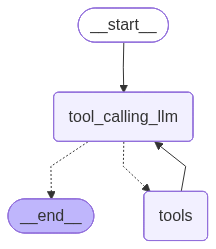

In [28]:
# Building a ReAct Agent chatbot with LangGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
# ToolNode - A node for executing tools in LangGraph workflows. It takes a list of tools and executes any that are called by the LLM, returning their outputs back into the workflow state.
from IPython.display import display, Image

# Define the state graph
builder = StateGraph(State)

# Add the node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
graph = builder.compile(name = "react_agent")

# Display the graph
Image(graph.get_graph().draw_mermaid_png())


In [ ]:
# Invocation

query = "Provide me 3 recent AI news for March 2026, add 5 plus 5 and then multiply by 10."

messages = graph.invoke({"messages": [HumanMessage(content=query)]})

for msg in messages['messages']:
    msg.pretty_print()

================================ Human Message =================================

Provide me 10 recent AI news for March 2026, add 5 plus 5 and then multiply by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_ep3eJfJPFQoTUrLZW7006CAn)
 Call ID: call_ep3eJfJPFQoTUrLZW7006CAn
  Args:
    query: AI news March 2026 recent major developments
    search_depth: advanced
    topic: general
    start_date: 2026-03-01
    end_date: 2026-03-31
    time_range: month
  aDD (call_nXWzrkTGCgceg06HPVL5HW0E)
 Call ID: call_nXWzrkTGCgceg06HPVL5HW0E
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
================================= Tool Message =================================
Name: aDD

10
================================== Ai Message ==========================

In [ ]:
# Invocation

query = "Provide me 3 recent AI news for March 2026, add 5 plus 5 and then multiply by 10."

messages = graph.invoke({"messages": [HumanMessage(content=query)]}, stream_mode="messages")

for message, metadata in messages:
    if isinstance(message, AIMessage):
        print(message.content, end="", flush=True)

Here are 10 recent AI news items for March 2026 based on available search results:

1. **AI data centers need faster links**  
   A mass-producible optical microchip could help improve interconnect speeds for AI data centers.  
   Source: Tech Xplore, Mar 22, 2026

2. **Highly performing AI agents can still fail to spot deception**  
   A study found that even advanced AI agents remain weak at detecting deception.  
   Source: Tech Xplore, Mar 21, 2026

3. **Neuro-symbolic AI may cut energy use and improve performance**  
   Researchers reported that neuro-symbolic AI could dramatically improve efficiency.  
   Source: Tech Xplore, Mar 2026

4. **Brain-inspired nanoelectronic device could reduce AI hardware energy use by 70%**  
   New hardware research points to major energy savings for AI systems.  
   Source: Tech Xplore, Mar 20, 2026

5. **Anthropic economists say AI has had limited labor-market impact so far**  
   A March report suggests AI is not yet eliminating as many jobs as 

In [ ]:
# Invocation

messages = graph.stream(
    {"messages": [HumanMessage(content="Plan to 3 days trip to goa. Don't book any thing just share the efficient budget plan under 10000.")]},
    stream_mode="messages")

for message, metadata in messages:
    if isinstance(message, AIMessage):
        print(message.content, end="", flush=True)

Here’s a simple **3-day Goa budget trip plan under ₹10,000 per person** without booking anything.

## Assumptions
- Starting from a nearby city by **train/bus**.  
- **Budget traveler** style.
- **1 person** estimate.
- Stay in **hostel / budget guesthouse**.
- Focus on **North + South Goa highlights** efficiently.

---

# Total Budget Target: **₹8,000–₹10,000**

## Rough Budget Breakdown
- **Travel to/from Goa**: ₹2,000–₹3,500
- **Stay for 2 nights**: ₹1,200–₹2,000
- **Local transport**: ₹1,200–₹1,800
- **Food**: ₹1,200–₹1,800
- **Sightseeing / misc.**: ₹800–₹1,200

---

# Best Budget Strategy
- Reach Goa **early morning Day 1**
- Leave **night of Day 3**
- Stay in **North Goa** only, so you avoid changing hotels
- Rent a **scooter** for 2 days for cheapest local travel
- Use **public bus / shared taxi** on arrival or departure if needed

---

# Ideal Area to Stay
Choose one base in **North Goa**:
- **Anjuna**
- **Vagator**
- **Calangute**
- **Baga** if you want busier nightlife

### 